# Experiment A — EventPointPose MPJPE and PCK vs Network Period

This notebook evaluates the **EventPointPose** Experiment A outputs produced by `EPP_run_expA.sh`.

It computes the same accuracy metrics used in the MoveEnetOFK analysis where they are applicable:

1. per-sequence and dataset-level **MPJPE**
2. dataset-level MPJPE population standard deviation
3. **PCK** at multiple normalized thresholds
4. per-joint MPJPE and PCK
5. MPJPE/PCK plots against network inference rate
6. optional GT-versus-prediction time traces for one sequence

Only quantities present in the EventPointPose experiment are used. There is no optical-flow period, MoveEnet-only branch, OFK branch, or method comparison.

The notebook supports the DHP19 output layout:

```text
dhp19_full_test/results/raw/
└── np_<network_period>/
    └── <sequence>__<channel>_net_flow_np_<network_period>.csv
```

In [5]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

from datasets.utils import constants as ds_constants, parsing as ds_parsing

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 200)

# Directory configuration and evaluation settings

In [6]:
# -----------------------------------------------------------------------------
# RESULTS DIRECTORY
# -----------------------------------------------------------------------------
DATA_DIR = next((p for p in (Path('/data'), Path.home() / 'data') if p.exists()), Path('/data'))
EXP_DATASET_DIR = DATA_DIR / 'MoveEnet_OFK_results/EPP_dhp19_full_test'
EXP_DIR = EXP_DATASET_DIR

# -----------------------------------------------------------------------------
# DHP19 INPUTS
# -----------------------------------------------------------------------------
DATASET = 'dhp19'
DATA_ROOT = DATA_DIR / 'dhp19_testing_set_S13toS17'
RAW_DIR = EXP_DATASET_DIR / 'results' / 'raw'

AUTO_FALLBACK_RAW_DIRS = [
    EXP_DIR / 'results' / 'raw',
]

# -----------------------------------------------------------------------------
# OUTPUT FOLDERS
# -----------------------------------------------------------------------------
SUMMARY_DIR = EXP_DATASET_DIR / 'results' / 'summary'
PLOTS_DIR = EXP_DATASET_DIR / 'plots'
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# EXPECTED EXPERIMENT SETTINGS
# -----------------------------------------------------------------------------
# These match the default network periods in EPP_run_expA.sh.
EXPECTED_NETWORK_PERIODS = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]

# PCK thresholds are normalized by the distance between two GT reference joints.
PCK_THRESHOLDS = [0.1, 0.2, 0.4, 0.6]
REF_JOINT_1 = 1
REF_JOINT_2 = 5

joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 joints, got {len(joint_names)}'

print('DATASET:', DATASET)
print('RAW_DIR:', RAW_DIR)
print('DATA_ROOT:', DATA_ROOT)
print('Expected network periods:', EXPECTED_NETWORK_PERIODS)
print('PCK thresholds:', PCK_THRESHOLDS)
print(
    f'PCK reference joints: {REF_JOINT_1} ({joint_names[REF_JOINT_1]}) '
    f'and {REF_JOINT_2} ({joint_names[REF_JOINT_2]})'
)

DATASET: dhp19
RAW_DIR: /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/results/raw
DATA_ROOT: /data/dhp19_testing_set_S13toS17
Expected network periods: [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
PCK thresholds: [0.1, 0.2, 0.4, 0.6]
PCK reference joints: 1 (shoulder_right) and 5 (hip_left)


# Utility functions

In [7]:
def resolve_raw_dir(raw_dir: Path, fallback_dirs):
    if raw_dir.exists():
        return raw_dir

    for fallback in fallback_dirs:
        if fallback.exists():
            print(f'RAW_DIR not found, falling back to: {fallback}')
            return fallback

    raise FileNotFoundError(
        f'Could not find RAW_DIR={raw_dir} and no fallback raw directory exists.'
    )


def tag_to_period(tag: str) -> float:
    return float(str(tag).replace('p', '.'))


def period_tag_from_folder(csv_path: Path) -> str:
    """Extract the network-period tag from RAW_DIR/np_<tag>/file.csv."""
    np_folder = csv_path.parent.name

    if not np_folder.startswith('np_'):
        raise ValueError(f'Unexpected network-period folder: {np_folder}')

    return np_folder.replace('np_', '', 1)


def load_pred_eval_csv(csv_path: Path):
    """
    Load one EventPointPose evaluation CSV.

    Expected columns:
        timestamp, latency,
        joint0_x, joint0_y, ...,
        joint12_x, joint12_y,
        optional additional columns

    Returns:
        timestamps: [N]
        joints: [N, 13, 2]
    """
    arr = np.loadtxt(csv_path, delimiter=',', skiprows=1)

    if arr.ndim == 1:
        arr = arr[None, :]

    if arr.shape[1] < 28:
        raise ValueError(
            f'Unexpected CSV format for {csv_path}: '
            f'expected at least 28 columns, found {arr.shape[1]}'
        )

    timestamps = arr[:, 0]
    joints = arr[:, 2:28].reshape(-1, 13, 2)
    return timestamps, joints


def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray) -> np.ndarray:
    """Interpolate DHP19 GT skeleton coordinates to prediction timestamps."""
    ts_gt_raw = np.asarray(gt_data['ts'])
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))

    joints_gt = np.zeros((len(ts_pred), 13, 2), dtype=np.float64)

    for joint_index, joint_name in enumerate(joint_names):
        x_raw = gt_data[joint_name][:, 0]
        y_raw = gt_data[joint_name][:, 1]

        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))

        joints_gt[:, joint_index, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, joint_index, 1] = np.interp(ts_pred, ts_gt, y)

    return joints_gt


COORD_LIMIT = 1e6


def invalid_joint_points(joints: np.ndarray) -> np.ndarray:
    """
    Return a boolean array with shape [N_frames, 13].

    A joint point is invalid if it contains NaN, infinity, or an unrealistically
    large coordinate.
    """
    return (
        ~np.isfinite(joints).all(axis=2)
        | (np.abs(joints) > COORD_LIMIT).any(axis=2)
    )


def calculate_pck_binary(
    joints_pred: np.ndarray,
    joints_gt: np.ndarray,
    threshold: float,
) -> np.ndarray:
    """Return PCK correctness values with shape [N_frames, 13]."""
    error_distance = np.linalg.norm(joints_pred - joints_gt, axis=2)

    reference_vector = (
        joints_gt[:, REF_JOINT_2, :]
        - joints_gt[:, REF_JOINT_1, :]
    )
    reference_distance = np.linalg.norm(reference_vector, axis=1)
    reference_distance = np.maximum(reference_distance, 1e-6)

    return (
        error_distance
        <= threshold * reference_distance[:, np.newaxis]
    ).astype(np.float32)


def extract_metadata_from_name(csv_path: Path):
    """
    Parse filenames generated by EPP_run_expA.sh.

    Expected format:
        <sequence_base>__<channel>_net_flow_np_<network_period>.csv

    Example:
        S13_1_1__ch2dvs_net_flow_np_0p05.csv

    Returns:
        sequence_key, network_period_s
    """
    name = csv_path.name.strip()
    period_pattern = r'\d+p\d+|\d+'

    pattern = (
        rf'(?P<sequence_base>.+?)__'
        rf'(?P<channel>ch\d+dvs)_'
        rf'net_flow_np_'
        rf'(?P<network_period>{period_pattern})'
        rf'(?:\.csv)?$'
    )

    match = re.fullmatch(pattern, name)

    if not match:
        raise ValueError(f'Unrecognized EventPointPose filename: {name}')

    sequence_key = (
        f"{match.group('sequence_base')}__{match.group('channel')}"
    )
    network_period_s = tag_to_period(match.group('network_period'))

    return sequence_key, network_period_s


def gt_path_from_seq_key(seq_key: str) -> Path:
    """
    Convert a DHP19 sequence key to its GT skeleton path.

    Example:
        S13_1_1__ch2dvs
        -> DATA_ROOT/S13_1_1/ch2GT200Hzskeleton/data.log
    """
    parts = seq_key.split('__')

    if len(parts) < 2 or not re.fullmatch(r'ch[23]dvs', parts[-1]):
        raise ValueError(
            "Expected a DHP19 sequence ending in '__ch2dvs' or '__ch3dvs'. "
            f'Got: {seq_key}'
        )

    channel_dvs = parts[-1]
    sequence_path = Path(*parts[:-1])
    gt_folder = channel_dvs.replace('dvs', 'GT200Hzskeleton')

    return DATA_ROOT / sequence_path / gt_folder / 'data.log'


def set_actual_x_ticks(ax, values):
    """Show a tick for every measured x value on a logarithmic axis."""
    ticks = sorted(pd.Series(values).dropna().unique())

    if len(ticks) == 0:
        return

    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{x:g}' for x in ticks])
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())


def plot_metric(
    table: pd.DataFrame,
    x_col: str,
    y_col: str,
    ylabel: str,
    title: str,
    output_path: Path,
    xscale: str = 'log',
    ylim=None,
    yerr_col=None,
):
    """Plot one EventPointPose curve over the network-period sweep."""
    data = table.sort_values(x_col)

    fig, ax = plt.subplots(figsize=(8, 5))

    if yerr_col is not None and yerr_col in data.columns:
        ax.errorbar(
            data[x_col],
            data[y_col],
            yerr=data[yerr_col],
            marker='o',
            linewidth=2,
            markersize=6,
            capsize=4,
            label='EventPointPose',
        )
    else:
        ax.plot(
            data[x_col],
            data[y_col],
            marker='o',
            linewidth=2,
            markersize=6,
            label='EventPointPose',
        )

    if xscale is not None:
        ax.set_xscale(xscale)

    set_actual_x_ticks(ax, data[x_col])

    if x_col == 'detection_rate_hz':
        ax.set_xlabel('Network inference rate (Hz)')
    else:
        ax.set_xlabel('Network period (s)')

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()

    print('Saved:', output_path)

# CSV discovery and metric calculation

In [8]:
RAW_DIR = resolve_raw_dir(RAW_DIR, AUTO_FALLBACK_RAW_DIRS)

csv_files = sorted(RAW_DIR.glob('np_*/*.csv'))

print('RAW_DIR:', RAW_DIR)
print(f'Found {len(csv_files)} prediction CSV files')

if len(csv_files) == 0:
    raise RuntimeError(
        'No CSV files found in RAW_DIR/np_*/*.csv. '
        'Check the EventPointPose experiment output path.'
    )

discovered_periods = sorted({
    tag_to_period(period_tag_from_folder(csv_path))
    for csv_path in csv_files
})

print('Discovered network periods:', discovered_periods)

missing_expected_periods = [
    period
    for period in EXPECTED_NETWORK_PERIODS
    if not any(np.isclose(period, found) for found in discovered_periods)
]

if missing_expected_periods:
    print('Warning: expected periods with no CSV files:', missing_expected_periods)

RAW_DIR: /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/results/raw
Found 480 prediction CSV files
Discovered network periods: [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]


In [9]:
gt_cache = {}
rows = []

print('Processing CSV files and computing per-sequence MPJPE + PCK...')

for csv_index, csv_path in enumerate(csv_files):
    if csv_index % 10 == 0:
        print(f'  [{csv_index}/{len(csv_files)}]')

    sequence_key, network_period_s = extract_metadata_from_name(csv_path)

    network_period_from_folder = tag_to_period(
        period_tag_from_folder(csv_path)
    )

    if not np.isclose(network_period_s, network_period_from_folder):
        raise ValueError(
            'Network period mismatch:\n'
            f'  CSV file: {csv_path.name} -> {network_period_s}\n'
            f'  Folder:   {csv_path.parent.name} '
            f'-> {network_period_from_folder}\n'
            f'  Full path: {csv_path}'
        )

    gt_path = gt_path_from_seq_key(sequence_key)

    if not gt_path.exists():
        print(f'Skipping missing GT: {gt_path}')
        continue

    if gt_path not in gt_cache:
        gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(
            gt_path,
            multi_channel=False,
        )

    gt_data = gt_cache[gt_path]

    ts_pred, joints_pred = load_pred_eval_csv(csv_path)
    joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)

    bad_pred = invalid_joint_points(joints_pred)
    bad_gt = invalid_joint_points(joints_gt)

    if bad_pred.any() or bad_gt.any():
        print('\n' + '=' * 80)
        print(f'Invalid coordinates found in sequence: {sequence_key}')
        print(f'Network period: {network_period_s}')
        print(f'CSV: {csv_path}')
        print(f'GT:  {gt_path}')
        print(
            'Invalid prediction joint points: '
            f'{bad_pred.sum()} / {bad_pred.size}'
        )
        print(
            'Invalid GT joint points: '
            f'{bad_gt.sum()} / {bad_gt.size}'
        )
        print('Skipping this CSV.')
        print('=' * 80)
        continue

    # -------------------------------------------------------------------------
    # MPJPE
    # -------------------------------------------------------------------------
    error = np.linalg.norm(joints_pred - joints_gt, axis=2)
    per_joint_error = error.mean(axis=0)

    n_samples = int(error.shape[0])
    n_points = int(error.size)

    row = {
        'csv_path': str(csv_path),
        'sequence': sequence_key,
        'network_period_s': network_period_s,
        'detection_rate_hz': 1.0 / network_period_s,
        'n_samples': n_samples,
        'n_points': n_points,
        'sum_err_px': float(np.sum(error, dtype=np.float64)),
        'sum_sq_err_px': float(
            np.sum(error * error, dtype=np.float64)
        ),
        'mpjpe_px': float(error.mean()),
        'mpjpe_std_px': float(error.std(ddof=0)),
    }

    for joint_index, joint_name in enumerate(joint_names):
        row[f'mpjpe_{joint_name}'] = float(
            per_joint_error[joint_index]
        )
        row[f'sum_err_{joint_name}'] = float(
            error[:, joint_index].sum()
        )

    # -------------------------------------------------------------------------
    # PCK
    # -------------------------------------------------------------------------
    for threshold in PCK_THRESHOLDS:
        pck_binary = calculate_pck_binary(
            joints_pred,
            joints_gt,
            threshold,
        )

        row[f'pck_{threshold:.1f}'] = float(
            pck_binary.mean() * 100.0
        )

        for joint_index, joint_name in enumerate(joint_names):
            row[f'pck_{threshold:.1f}_{joint_name}'] = float(
                pck_binary[:, joint_index].mean() * 100.0
            )

    rows.append(row)

if len(rows) == 0:
    raise RuntimeError(
        'No valid rows were generated. Check GT paths and prediction CSV files.'
    )

df_seq = (
    pd.DataFrame(rows)
    .sort_values([
        'network_period_s',
        'sequence',
    ])
    .reset_index(drop=True)
)

print(
    f'Processed {len(df_seq)} valid sequence/network-period rows '
    f'from {df_seq["sequence"].nunique()} sequences'
)

Processing CSV files and computing per-sequence MPJPE + PCK...
  [0/480]
  [10/480]
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
  [20/480]
  [30/480]
  [40/480]
  [50/480]
  [60/480]
  [70/480]
  [80/480]
  [90/480]
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
  [100/480]
  [110/480]
  [120/480]
  [130/480]
  [140/480]
  [150/480]
  [160/480]
  [170/480]
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
  [180/480]
  [190/480]
  [200/480]
  [210/480]
  [220/480]
  [230/480]
  [240/480]
  [250/480]
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
  [260/480]
  [270/480]
  [280/480]
  [290/480]
  [300/480]
  [310/480]
  [320/480]
  [330/480]
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
  [340/480]
  [350/480]
  [360/480]
  [370/480]
  [380/480]
  [390/480]
  [400/480]
  [410

In [10]:
if len(df_seq) == 0:
    raise RuntimeError('No valid sequence rows to aggregate.')

group_cols = [
    'network_period_s',
    'detection_rate_hz',
]

pck_cols = [
    f'pck_{threshold:.1f}'
    for threshold in PCK_THRESHOLDS
    if f'pck_{threshold:.1f}' in df_seq.columns
]

# -----------------------------------------------------------------------------
# DATASET-LEVEL WEIGHTED AGGREGATION
# -----------------------------------------------------------------------------
# MPJPE mean and standard deviation are calculated over every evaluated joint
# point, not as an unweighted mean of sequence-level means.
#
# PCK percentages are converted back into correct-point counts before
# aggregation.
# -----------------------------------------------------------------------------
work = df_seq.copy()

for pck_col in pck_cols:
    work[f'{pck_col}_correct_points'] = (
        work[pck_col] / 100.0
    ) * work['n_points']

agg_dict = {
    'sum_err_px': ('sum_err_px', 'sum'),
    'sum_sq_err_px': ('sum_sq_err_px', 'sum'),
    'n_points': ('n_points', 'sum'),
    'n_samples': ('n_samples', 'sum'),
    'n_sequences': ('sequence', 'nunique'),
}

for pck_col in pck_cols:
    agg_dict[f'{pck_col}_correct_points'] = (
        f'{pck_col}_correct_points',
        'sum',
    )

df_table = (
    work
    .groupby(group_cols, as_index=False)
    .agg(**agg_dict)
)

df_table['mpjpe_px'] = (
    df_table['sum_err_px']
    / df_table['n_points']
)

mpjpe_variance = (
    df_table['sum_sq_err_px'] / df_table['n_points']
    - df_table['mpjpe_px'] ** 2
)

df_table['mpjpe_std_px'] = np.sqrt(
    np.maximum(mpjpe_variance, 0.0)
)

for pck_col in pck_cols:
    df_table[pck_col] = (
        df_table[f'{pck_col}_correct_points']
        / df_table['n_points']
        * 100.0
    )

df_table = df_table.drop(
    columns=[
        f'{pck_col}_correct_points'
        for pck_col in pck_cols
    ]
)

df_table = (
    df_table
    .sort_values('network_period_s')
    .reset_index(drop=True)
)

print(f'Created {len(df_table)} dataset-level configurations')
display(df_table)

Created 6 dataset-level configurations


,network_period_s,detection_rate_hz,sum_err_px,sum_sq_err_px,n_points,n_samples,n_sequences,mpjpe_px,mpjpe_std_px,pck_0.1,pck_0.2,pck_0.4,pck_0.6
0,0.01,100.0,7.332598e+07,3.447284e+09,2311985,177845,79,31.715594,22.026585,3.978919,14.554204,40.575393,61.446376
1,0.02,50.0,3.695418e+07,1.751976e+09,1156571,88967,79,31.951499,22.223945,3.950817,14.402402,40.155771,60.823244
2,0.05,20.0,1.508926e+07,7.291904e+08,463203,35631,79,32.575912,22.650495,3.783007,13.859150,38.961967,59.503717
3,0.10,10.0,7.694693e+06,3.778697e+08,232128,17856,79,33.148493,23.000613,3.535549,13.315929,37.569789,58.543131
4,0.20,5.0,3.924442e+06,1.944644e+08,116545,8965,79,33.673192,23.123447,3.296581,12.674074,36.216912,57.322923
5,0.50,2.0,1.617193e+06,8.096507e+07,47294,3638,79,34.194471,23.295717,3.087072,12.166448,35.264516,56.011333


In [11]:
per_sequence_path = (
    SUMMARY_DIR / 'dhp19_eventpointpose_per_sequence_metrics.csv'
)
dataset_path = (
    SUMMARY_DIR / 'dhp19_eventpointpose_dataset_metrics.csv'
)

df_seq.to_csv(per_sequence_path, index=False)
df_table.to_csv(dataset_path, index=False)

print('Saved per-sequence metrics:', per_sequence_path)
print('Saved dataset metrics:     ', dataset_path)

Saved per-sequence metrics: /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/results/summary/dhp19_eventpointpose_per_sequence_metrics.csv
Saved dataset metrics:      /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/results/summary/dhp19_eventpointpose_dataset_metrics.csv


# Dataset-level MPJPE and PCK plots

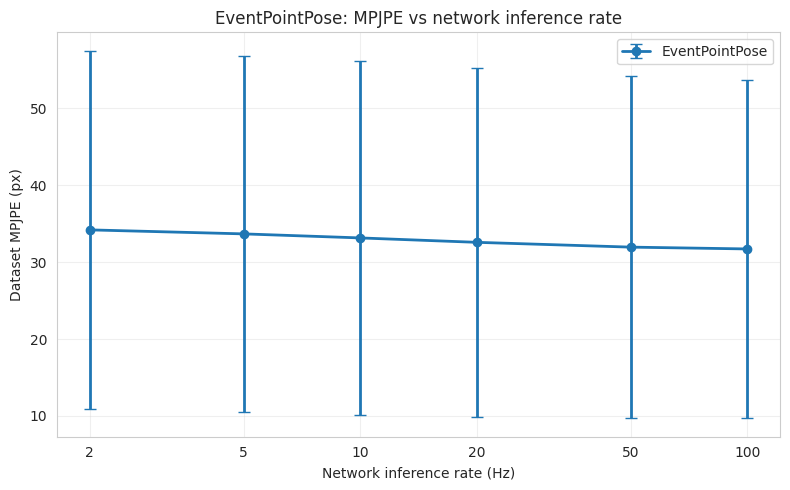

Saved: /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/plots/eventpointpose_mpjpe_mean_std_vs_detection_rate.png


In [12]:
mpjpe_plot_path = (
    PLOTS_DIR / 'eventpointpose_mpjpe_mean_std_vs_detection_rate.png'
)

plot_metric(
    table=df_table,
    x_col='detection_rate_hz',
    y_col='mpjpe_px',
    yerr_col='mpjpe_std_px',
    ylabel='Dataset MPJPE (px)',
    title='EventPointPose: MPJPE vs network inference rate',
    output_path=mpjpe_plot_path,
    xscale='log',
)

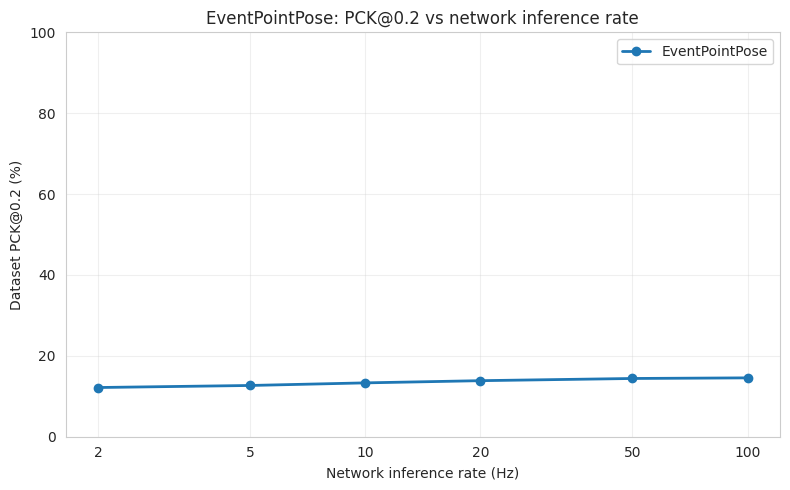

Saved: /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/plots/eventpointpose_pck_0.2_vs_detection_rate.png


In [13]:
PRIMARY_PCK_THRESHOLD = 0.2
primary_pck_col = f'pck_{PRIMARY_PCK_THRESHOLD:.1f}'

if primary_pck_col not in df_table.columns:
    raise RuntimeError(f'Missing PCK column: {primary_pck_col}')

pck_plot_path = (
    PLOTS_DIR
    / f'eventpointpose_pck_{PRIMARY_PCK_THRESHOLD:.1f}_vs_detection_rate.png'
)

plot_metric(
    table=df_table,
    x_col='detection_rate_hz',
    y_col=primary_pck_col,
    ylabel=f'Dataset PCK@{PRIMARY_PCK_THRESHOLD:.1f} (%)',
    title=(
        f'EventPointPose: PCK@{PRIMARY_PCK_THRESHOLD:.1f} '
        'vs network inference rate'
    ),
    output_path=pck_plot_path,
    xscale='log',
    ylim=(0, 100),
)

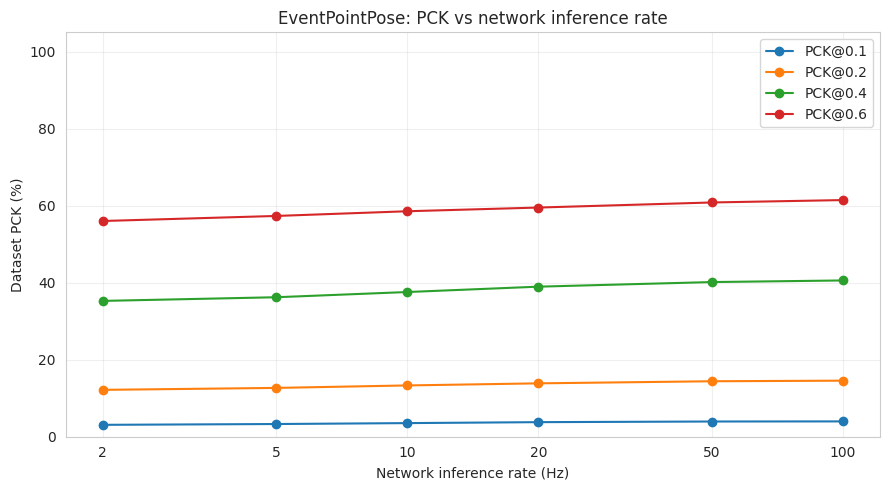

Saved: /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/plots/eventpointpose_pck_all_thresholds_vs_detection_rate.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

data = df_table.sort_values('detection_rate_hz')

for threshold in PCK_THRESHOLDS:
    pck_col = f'pck_{threshold:.1f}'

    if pck_col not in data.columns:
        continue

    ax.plot(
        data['detection_rate_hz'],
        data[pck_col],
        marker='o',
        label=f'PCK@{threshold:.1f}',
    )

ax.set_xscale('log')
set_actual_x_ticks(ax, data['detection_rate_hz'])
ax.set_xlabel('Network inference rate (Hz)')
ax.set_ylabel('Dataset PCK (%)')
ax.set_title('EventPointPose: PCK vs network inference rate')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

all_pck_plot_path = (
    PLOTS_DIR / 'eventpointpose_pck_all_thresholds_vs_detection_rate.png'
)
plt.savefig(all_pck_plot_path, dpi=180, bbox_inches='tight')
plt.show()

print('Saved:', all_pck_plot_path)

,network_period_s,detection_rate_hz,n_sequences,n_samples,n_points,mpjpe_px,mpjpe_std_px,pck_0.1,pck_0.2,pck_0.4,pck_0.6
0,0.01,100.0,79,177845,2311985,31.715594,22.026585,3.978919,14.554204,40.575393,61.446376
1,0.02,50.0,79,88967,1156571,31.951499,22.223945,3.950817,14.402402,40.155771,60.823244
2,0.05,20.0,79,35631,463203,32.575912,22.650495,3.783007,13.859150,38.961967,59.503717
3,0.10,10.0,79,17856,232128,33.148493,23.000613,3.535549,13.315929,37.569789,58.543131
4,0.20,5.0,79,8965,116545,33.673192,23.123447,3.296581,12.674074,36.216912,57.322923
5,0.50,2.0,79,3638,47294,34.194471,23.295717,3.087072,12.166448,35.264516,56.011333


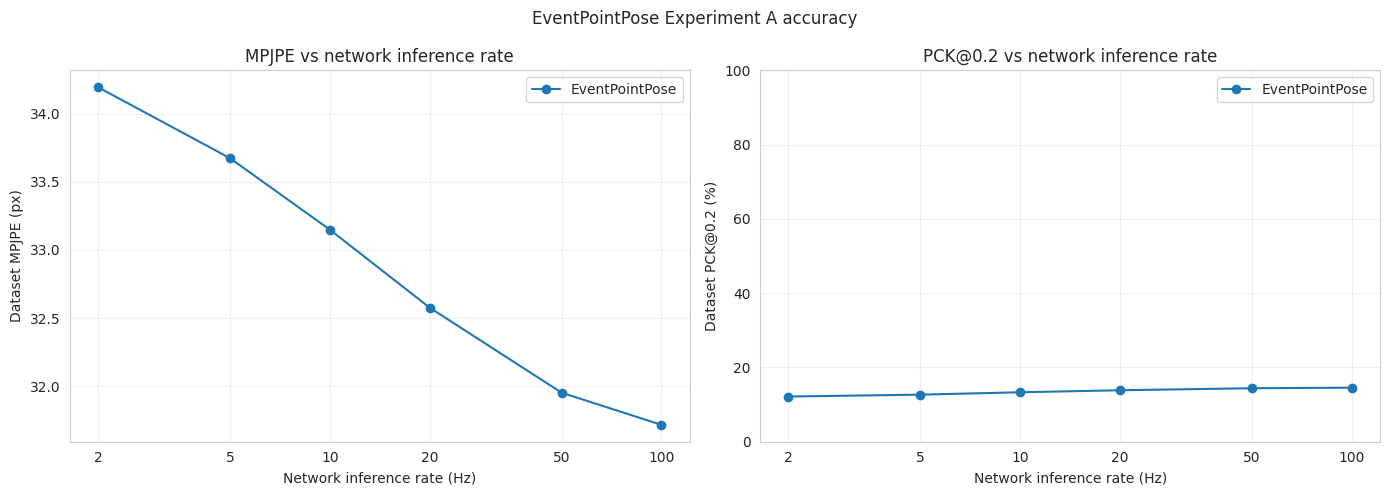

Saved: /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/plots/eventpointpose_combined_mpjpe_pck_0.2.png


In [15]:
compact_cols = [
    'network_period_s',
    'detection_rate_hz',
    'n_sequences',
    'n_samples',
    'n_points',
    'mpjpe_px',
    'mpjpe_std_px',
] + [
    f'pck_{threshold:.1f}'
    for threshold in PCK_THRESHOLDS
    if f'pck_{threshold:.1f}' in df_table.columns
]

compact_table = df_table[compact_cols].copy()
display(compact_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_data = df_table.sort_values('detection_rate_hz')

axes[0].plot(
    plot_data['detection_rate_hz'],
    plot_data['mpjpe_px'],
    marker='o',
    label='EventPointPose',
)
axes[1].plot(
    plot_data['detection_rate_hz'],
    plot_data[primary_pck_col],
    marker='o',
    label='EventPointPose',
)

for ax in axes:
    ax.set_xscale('log')
    set_actual_x_ticks(ax, plot_data['detection_rate_hz'])
    ax.set_xlabel('Network inference rate (Hz)')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Dataset MPJPE (px)')
axes[0].set_title('MPJPE vs network inference rate')

axes[1].set_ylabel(
    f'Dataset PCK@{PRIMARY_PCK_THRESHOLD:.1f} (%)'
)
axes[1].set_title(
    f'PCK@{PRIMARY_PCK_THRESHOLD:.1f} vs network inference rate'
)
axes[1].set_ylim(0, 100)

plt.suptitle('EventPointPose Experiment A accuracy')
plt.tight_layout()

combined_plot_path = (
    PLOTS_DIR
    / f'eventpointpose_combined_mpjpe_pck_{PRIMARY_PCK_THRESHOLD:.1f}.png'
)
plt.savefig(combined_plot_path, dpi=180, bbox_inches='tight')
plt.show()

print('Saved:', combined_plot_path)

# Dataset-level per-joint metrics

In [16]:
per_joint_mpjpe_cols = [
    f'mpjpe_{joint_name}'
    for joint_name in joint_names
]
sum_joint_cols = [
    f'sum_err_{joint_name}'
    for joint_name in joint_names
]

missing_sum_cols = [
    column
    for column in sum_joint_cols
    if column not in df_seq.columns
]

if missing_sum_cols:
    raise RuntimeError(
        f'Missing per-joint error sum columns: {missing_sum_cols[:5]}'
    )

joint_agg_dict = {
    'n_samples': ('n_samples', 'sum'),
    'n_sequences': ('sequence', 'nunique'),
}

for sum_column in sum_joint_cols:
    joint_agg_dict[sum_column] = (sum_column, 'sum')

agg_mpjpe_joints = (
    df_seq
    .groupby(group_cols, as_index=False)
    .agg(**joint_agg_dict)
)

for joint_name in joint_names:
    agg_mpjpe_joints[f'mpjpe_{joint_name}'] = (
        agg_mpjpe_joints[f'sum_err_{joint_name}']
        / agg_mpjpe_joints['n_samples']
    )

agg_mpjpe_joints = (
    agg_mpjpe_joints[
        group_cols
        + ['n_sequences', 'n_samples']
        + per_joint_mpjpe_cols
    ]
    .sort_values('network_period_s')
    .reset_index(drop=True)
)

per_joint_mpjpe_path = (
    SUMMARY_DIR
    / 'eventpointpose_mpjpe_per_joint_dataset_weighted.csv'
)
agg_mpjpe_joints.to_csv(per_joint_mpjpe_path, index=False)

print('Saved:', per_joint_mpjpe_path)
display(agg_mpjpe_joints)

Saved: /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/results/summary/eventpointpose_mpjpe_per_joint_dataset_weighted.csv


,network_period_s,detection_rate_hz,n_sequences,n_samples,mpjpe_head,mpjpe_shoulder_right,mpjpe_shoulder_left,mpjpe_elbow_right,mpjpe_elbow_left,mpjpe_hip_left,mpjpe_hip_right,mpjpe_wrist_right,mpjpe_wrist_left,mpjpe_knee_right,mpjpe_knee_left,mpjpe_ankle_right,mpjpe_ankle_left
0,0.01,100.0,79,177845,32.484972,26.195802,28.278901,23.678921,31.029853,26.924226,24.825564,41.544913,49.218909,23.869819,31.614857,29.920771,42.715215
1,0.02,50.0,79,88967,33.006686,26.684411,28.798878,24.125291,30.949456,27.372360,25.198548,41.746486,50.044866,23.763344,31.319346,29.988464,42.371349
2,0.05,20.0,79,35631,34.192348,27.613408,29.948923,24.992308,31.493826,28.327803,26.152421,42.295375,52.325278,23.869562,30.967720,29.854289,41.453594
3,0.10,10.0,79,17856,35.275278,28.809097,31.073848,26.231624,31.711016,29.038018,27.240342,42.953363,53.582938,23.944358,30.694220,29.992479,40.383830
4,0.20,5.0,79,8965,36.362005,29.858022,32.041371,27.627951,31.734144,29.756549,28.325507,43.904968,53.437487,24.604136,30.320936,30.406096,39.372329
5,0.50,2.0,79,3638,37.216728,30.835984,32.706742,28.573018,31.833050,30.342186,29.181687,44.322128,54.724433,25.056809,30.284927,30.757416,38.693009


In [17]:
work_joint_pck = df_seq.copy()
pck_joint_cols = []

for threshold in PCK_THRESHOLDS:
    for joint_name in joint_names:
        pck_col = f'pck_{threshold:.1f}_{joint_name}'

        if pck_col not in work_joint_pck.columns:
            continue

        pck_joint_cols.append(pck_col)
        work_joint_pck[f'{pck_col}_correct_samples'] = (
            work_joint_pck[pck_col] / 100.0
        ) * work_joint_pck['n_samples']

joint_pck_agg_dict = {
    'n_samples': ('n_samples', 'sum'),
    'n_sequences': ('sequence', 'nunique'),
}

for pck_col in pck_joint_cols:
    count_col = f'{pck_col}_correct_samples'
    joint_pck_agg_dict[count_col] = (count_col, 'sum')

agg_pck_joints = (
    work_joint_pck
    .groupby(group_cols, as_index=False)
    .agg(**joint_pck_agg_dict)
)

for pck_col in pck_joint_cols:
    agg_pck_joints[pck_col] = (
        agg_pck_joints[f'{pck_col}_correct_samples']
        / agg_pck_joints['n_samples']
        * 100.0
    )

agg_pck_joints = agg_pck_joints.drop(
    columns=[
        f'{pck_col}_correct_samples'
        for pck_col in pck_joint_cols
    ]
)

agg_pck_joints = (
    agg_pck_joints
    .sort_values('network_period_s')
    .reset_index(drop=True)
)

per_joint_pck_path = (
    SUMMARY_DIR
    / 'eventpointpose_pck_per_joint_dataset_weighted.csv'
)
agg_pck_joints.to_csv(per_joint_pck_path, index=False)

print('Saved:', per_joint_pck_path)
display(agg_pck_joints)

Saved: /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/results/summary/eventpointpose_pck_per_joint_dataset_weighted.csv


/tmp/ipykernel_100065/38234342.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg_pck_joints[pck_col] = (
/tmp/ipykernel_100065/38234342.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg_pck_joints[pck_col] = (
/tmp/ipykernel_100065/38234342.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.cop

,network_period_s,detection_rate_hz,n_samples,n_sequences,pck_0.1_head,pck_0.1_shoulder_right,pck_0.1_shoulder_left,pck_0.1_elbow_right,pck_0.1_elbow_left,pck_0.1_hip_left,pck_0.1_hip_right,pck_0.1_wrist_right,pck_0.1_wrist_left,pck_0.1_knee_right,pck_0.1_knee_left,pck_0.1_ankle_right,pck_0.1_ankle_left,pck_0.2_head,pck_0.2_shoulder_right,pck_0.2_shoulder_left,pck_0.2_elbow_right,pck_0.2_elbow_left,pck_0.2_hip_left,pck_0.2_hip_right,pck_0.2_wrist_right,pck_0.2_wrist_left,pck_0.2_knee_right,pck_0.2_knee_left,pck_0.2_ankle_right,pck_0.2_ankle_left,pck_0.4_head,pck_0.4_shoulder_right,pck_0.4_shoulder_left,pck_0.4_elbow_right,pck_0.4_elbow_left,pck_0.4_hip_left,pck_0.4_hip_right,pck_0.4_wrist_right,pck_0.4_wrist_left,pck_0.4_knee_right,pck_0.4_knee_left,pck_0.4_ankle_right,pck_0.4_ankle_left,pck_0.6_head,pck_0.6_shoulder_right,pck_0.6_shoulder_left,pck_0.6_elbow_right,pck_0.6_elbow_left,pck_0.6_hip_left,pck_0.6_hip_right,pck_0.6_wrist_right,pck_0.6_wrist_left,pck_0.6_knee_right,pck_0.6_knee_left,pck_0.6_ankle_right,pck_0.6_ankle_left
0,0.01,100.0,177845,79,1.905030,4.160927,4.302061,5.061149,2.791757,6.658045,5.777503,2.320560,1.766145,4.855914,5.341730,4.234024,2.551098,7.897889,17.348253,13.857573,18.873176,10.222385,19.645759,21.802693,9.759622,6.406702,18.855183,18.500380,15.474711,10.560319,33.253676,47.002727,38.952458,54.179763,36.243358,46.848098,51.168714,26.305491,23.225843,54.234868,40.925525,45.638056,29.501532,57.905480,68.559139,64.473559,77.518064,58.903540,66.767129,71.920492,44.018668,39.848745,78.958644,59.000815,67.904074,43.024544
1,0.02,50.0,88967,79,1.954657,4.010476,3.901447,4.868097,2.941540,6.387762,6.396754,2.226668,1.551137,4.982746,5.489676,3.967763,2.681893,7.890566,17.083863,13.153192,18.552947,10.742185,19.309407,21.600144,9.427091,6.082030,19.137433,18.420313,15.098857,10.733193,32.052334,45.513505,38.109636,52.690324,36.926051,45.408972,49.987074,25.964683,22.908494,54.782110,41.701979,45.736059,30.243798,55.929727,67.408140,63.045849,76.272101,58.722897,65.672665,70.829633,43.274473,39.665269,79.118100,59.637843,67.816157,43.309317
2,0.05,20.0,35631,79,1.928096,3.642895,3.496955,4.664478,2.862676,5.697286,6.031265,2.051584,1.448177,4.990037,5.060200,3.906710,3.398726,7.521540,15.772782,11.874491,17.119924,10.423508,17.554938,20.134153,8.952878,5.941456,19.334287,17.855238,16.311639,11.372120,29.917768,42.628610,35.769414,50.225927,35.631894,42.451797,46.639162,25.404844,22.138026,55.114928,42.493896,46.361315,31.727989,52.210154,65.297073,59.681177,74.118043,57.935505,63.806797,68.760349,42.370408,38.250400,78.976172,60.657854,67.160619,44.323763
3,0.10,10.0,17856,79,1.646505,3.270609,3.444220,3.909050,3.197805,5.163530,5.404346,1.864919,1.444892,4.749104,4.693100,3.371416,3.802643,7.291667,14.040099,11.458333,15.188172,11.357527,16.028226,17.758737,8.389337,5.925179,19.494848,17.366711,16.817876,11.990367,27.531362,39.521730,33.434140,46.622984,34.677419,39.572132,42.736335,23.454301,22.289427,55.762769,43.408378,46.163754,33.232527,48.756721,63.256049,56.558020,71.639785,58.232527,62.724014,67.025090,40.507393,38.457662,79.172267,62.102374,66.655466,45.973342
4,0.20,5.0,8965,79,1.561629,2.799777,3.045176,3.167875,2.744004,4.885666,5.309537,1.572783,1.238148,5.108756,3.848299,3.591746,3.982153,6.491913,12.548801,10.607920,13.117680,11.210262,15.013943,15.962075,7.406581,5.989961,20.189626,16.687117,17.311768,12.225321,25.644172,37.122142,30.909091,43.736754,34.010039,37.401004,39.475739,21.628555,23.547128,53.775795,44.506414,45.064138,33.998885,46.279978,61.137758,54.210820,68.555493,59.107641,60.959286,64.997211,38.271054,39.341885,77.166759,63.680981,64.551032,46.938093
5,0.50,2.0,3638,79,1.291919,2.968664,2.831226,3.243540,2.941176,5.002749,4.233095,1.456844,1.649258,4.150632,3.188565,2.913689,4.260583,6.019791,10.637713,9.538208,12.809236,11.654755,13.826278,14.925783,7.119296,6.157229,18.829027,15.722925,18.114349,12.809236,23.227048,34.936779,30.098956,40.984057,33.727323,35.486531,37.7130

# Text summary

In [18]:
print('=' * 100)
print('EVENTPOINTPOSE EXPERIMENT A - MPJPE AND PCK SUMMARY')
print('Aggregation: dataset-level weighted by evaluated joint/sample count')
print('=' * 100)

for _, row in df_table.sort_values('network_period_s').iterrows():
    period_s = float(row['network_period_s'])
    rate_hz = float(row['detection_rate_hz'])
    n_sequences = int(row['n_sequences'])
    n_samples = int(row['n_samples'])
    n_points = int(row['n_points'])

    print(
        f'\nNetwork period: {period_s:g} s '
        f'| Network inference rate: {rate_hz:g} Hz'
    )
    print(
        f"  MPJPE: {row['mpjpe_px']:.3f} ± "
        f"{row['mpjpe_std_px']:.3f} px"
    )
    print(
        f'  Sequences: {n_sequences} '
        f'| Samples: {n_samples} '
        f'| Joint points: {n_points}'
    )

    for threshold in PCK_THRESHOLDS:
        pck_col = f'pck_{threshold:.1f}'

        if pck_col in row.index:
            print(
                f"  PCK@{threshold:.1f}: "
                f"{row[pck_col]:.2f}%"
            )

print('\nSaved outputs:')
print('  Summary CSVs ->', SUMMARY_DIR)
print('  Plots        ->', PLOTS_DIR)
print('=' * 100)

EVENTPOINTPOSE EXPERIMENT A - MPJPE AND PCK SUMMARY
Aggregation: dataset-level weighted by evaluated joint/sample count

Network period: 0.01 s | Network inference rate: 100 Hz
  MPJPE: 31.716 ± 22.027 px
  Sequences: 79 | Samples: 177845 | Joint points: 2311985
  PCK@0.1: 3.98%
  PCK@0.2: 14.55%
  PCK@0.4: 40.58%
  PCK@0.6: 61.45%

Network period: 0.02 s | Network inference rate: 50 Hz
  MPJPE: 31.951 ± 22.224 px
  Sequences: 79 | Samples: 88967 | Joint points: 1156571
  PCK@0.1: 3.95%
  PCK@0.2: 14.40%
  PCK@0.4: 40.16%
  PCK@0.6: 60.82%

Network period: 0.05 s | Network inference rate: 20 Hz
  MPJPE: 32.576 ± 22.650 px
  Sequences: 79 | Samples: 35631 | Joint points: 463203
  PCK@0.1: 3.78%
  PCK@0.2: 13.86%
  PCK@0.4: 38.96%
  PCK@0.6: 59.50%

Network period: 0.1 s | Network inference rate: 10 Hz
  MPJPE: 33.148 ± 23.001 px
  Sequences: 79 | Samples: 17856 | Joint points: 232128
  PCK@0.1: 3.54%
  PCK@0.2: 13.32%
  PCK@0.4: 37.57%
  PCK@0.6: 58.54%

Network period: 0.2 s | Network 

# Optional time traces for one sequence

SELECTED_SEQUENCE was None, using: S13_1_1__ch2dvs
Prediction CSV: /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/results/raw/np_0p05/S13_1_1__ch2dvs_net_flow_np_0p05.csv
GT file:        /data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT200Hzskeleton/data.log


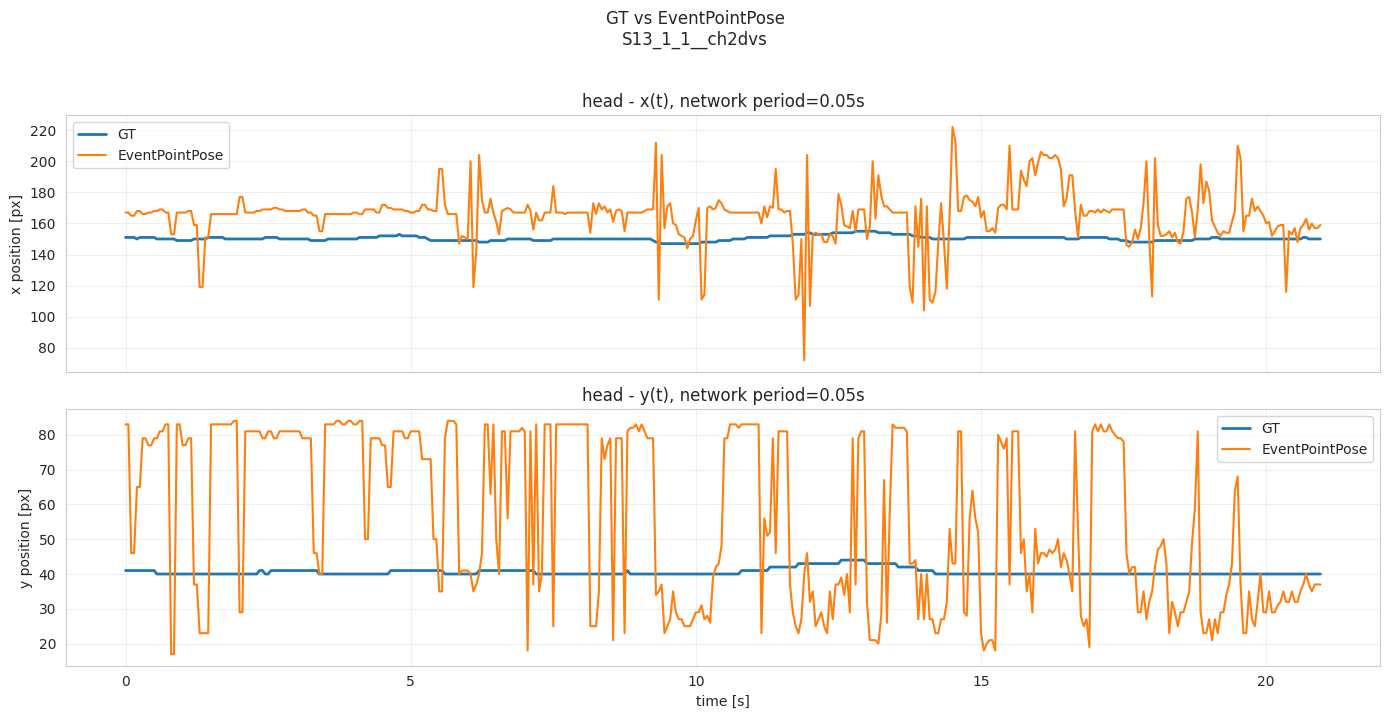

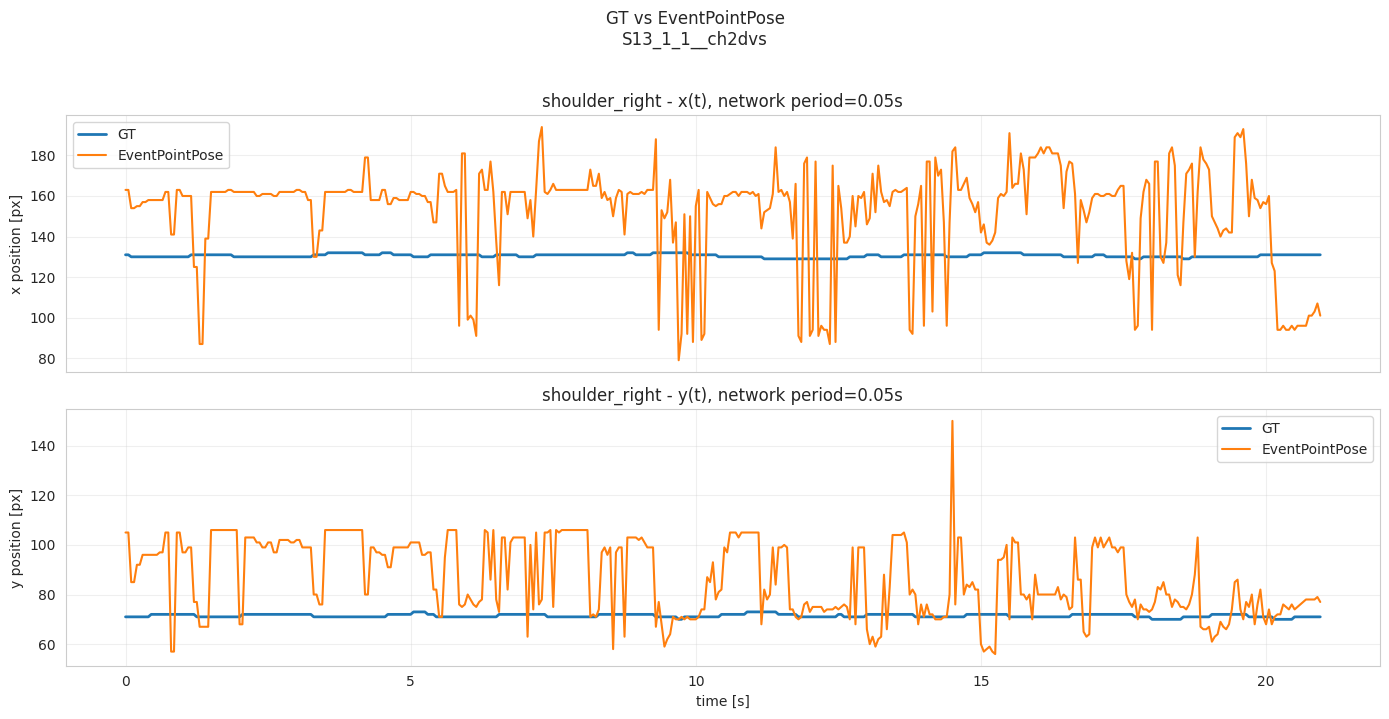

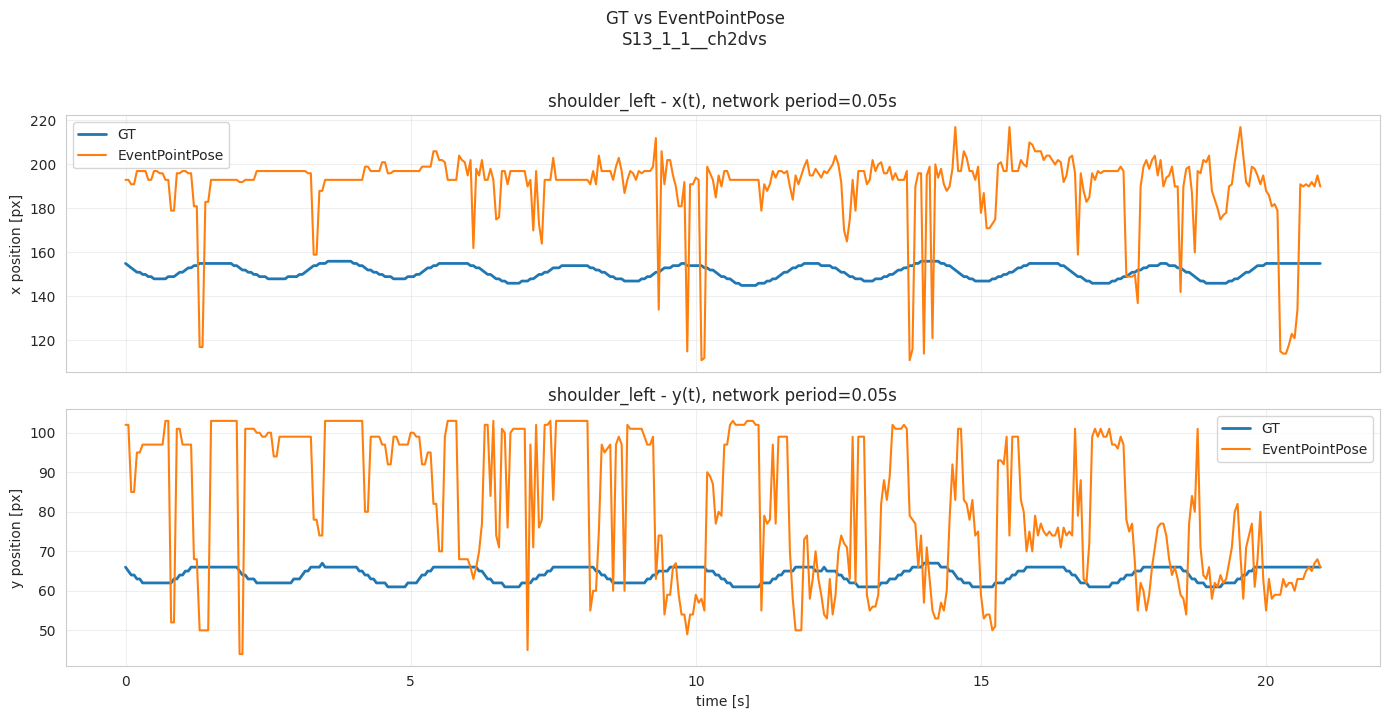

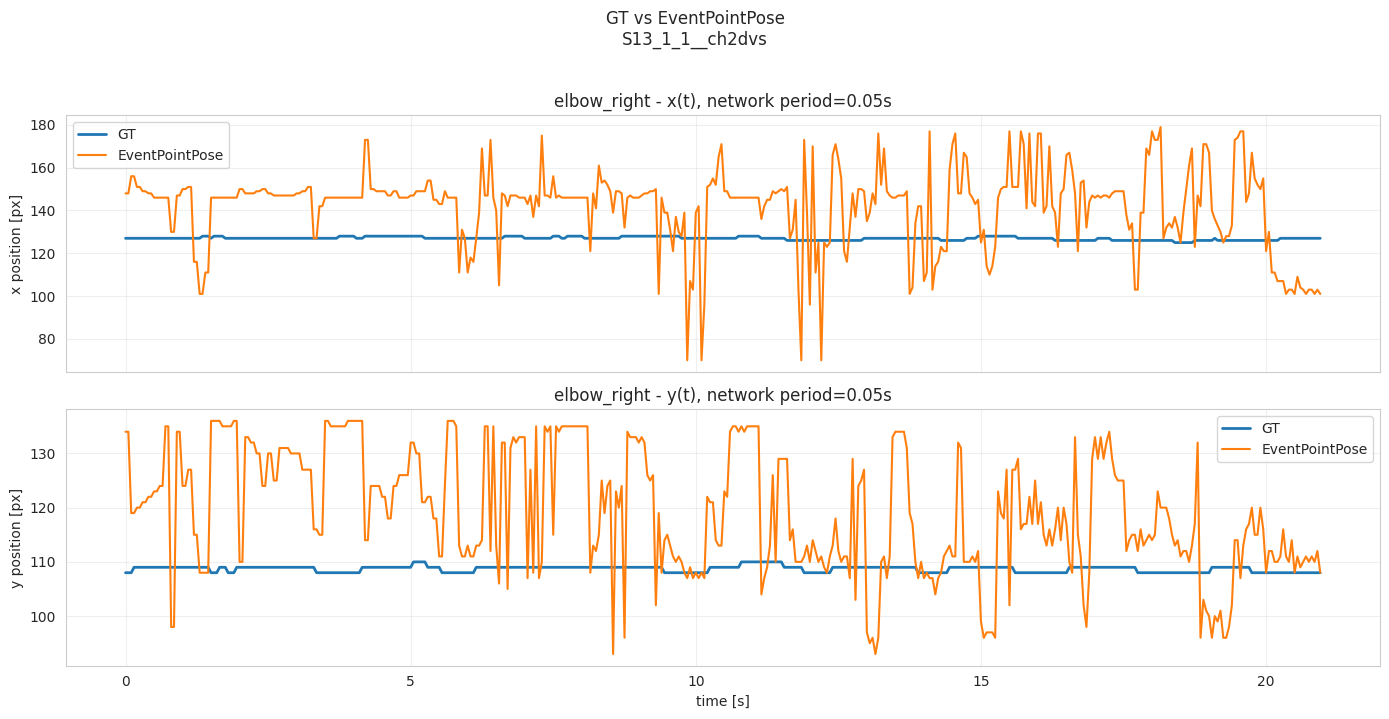

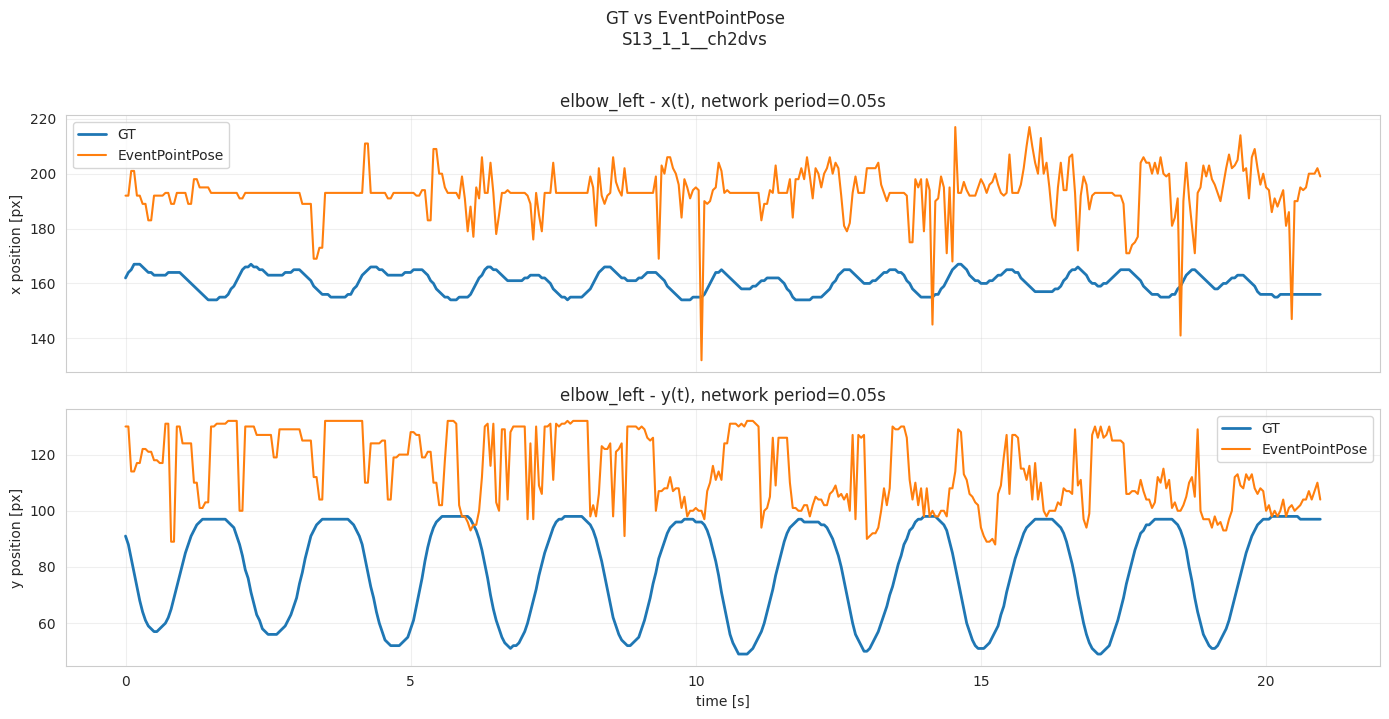

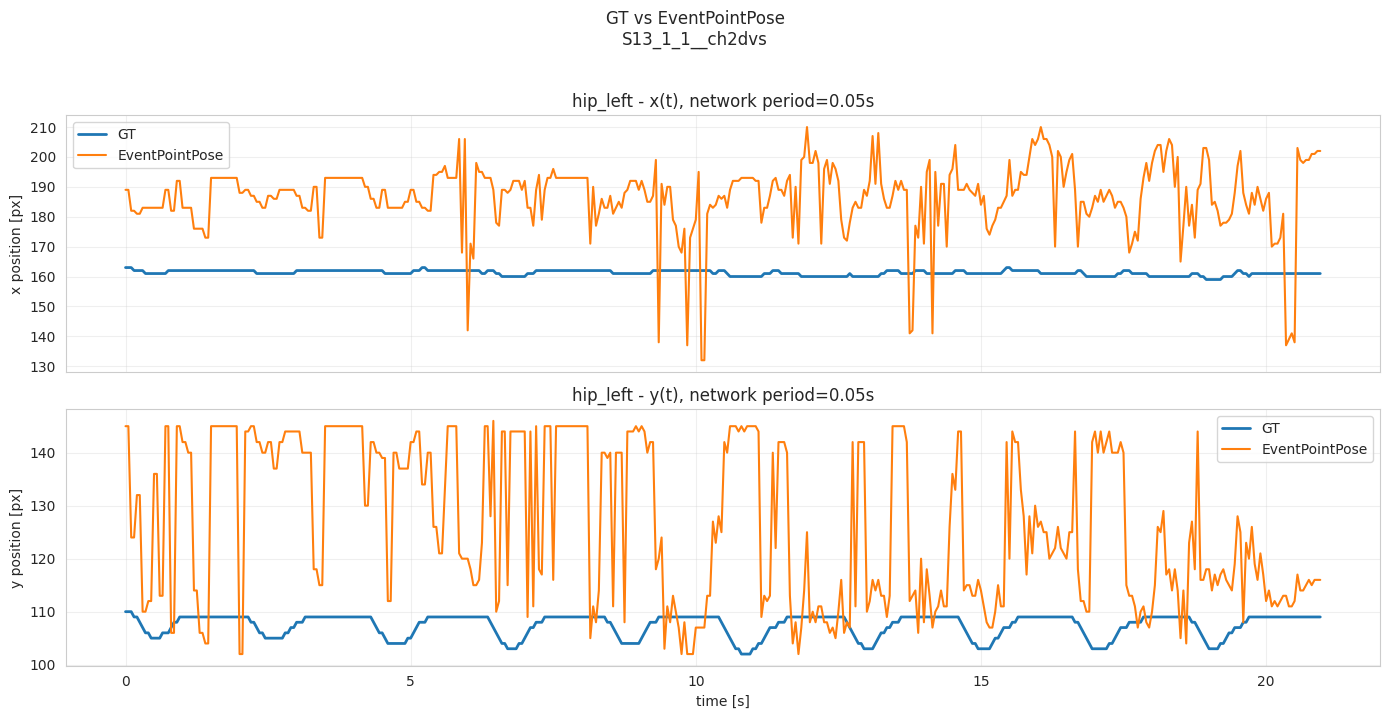

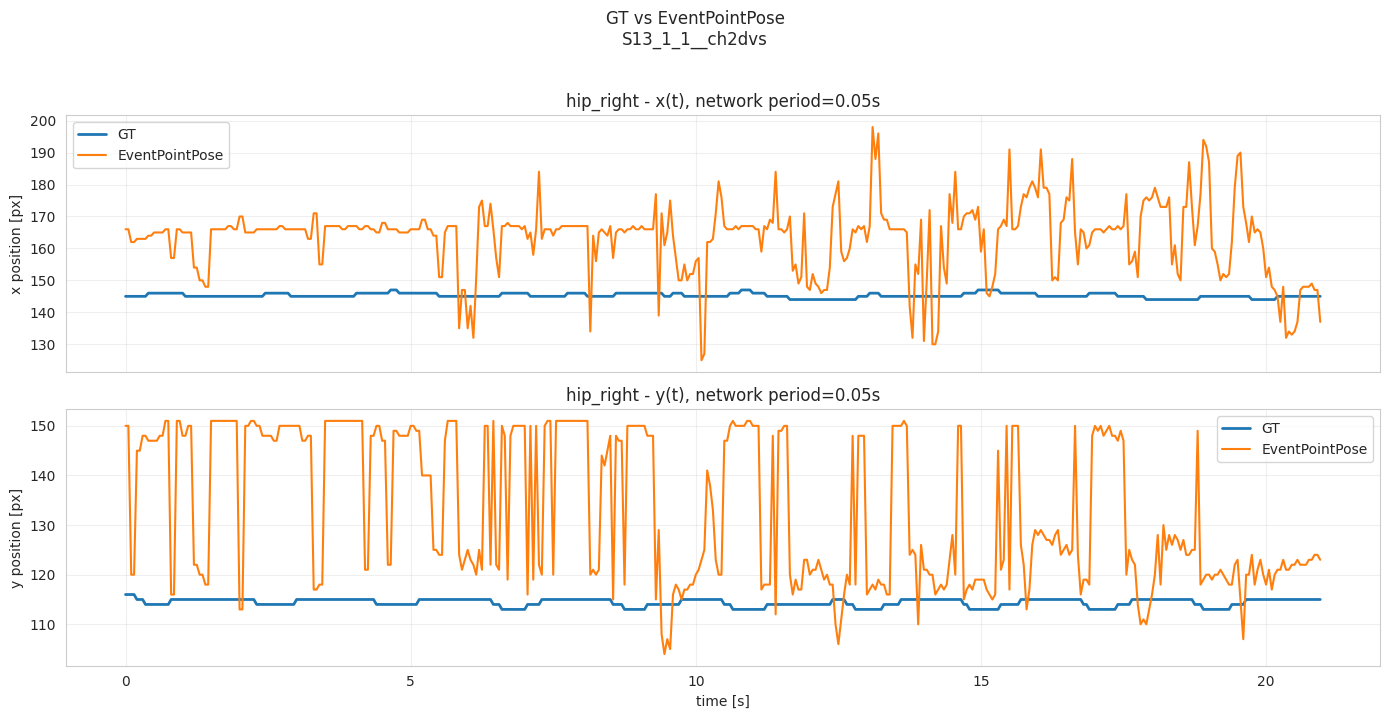

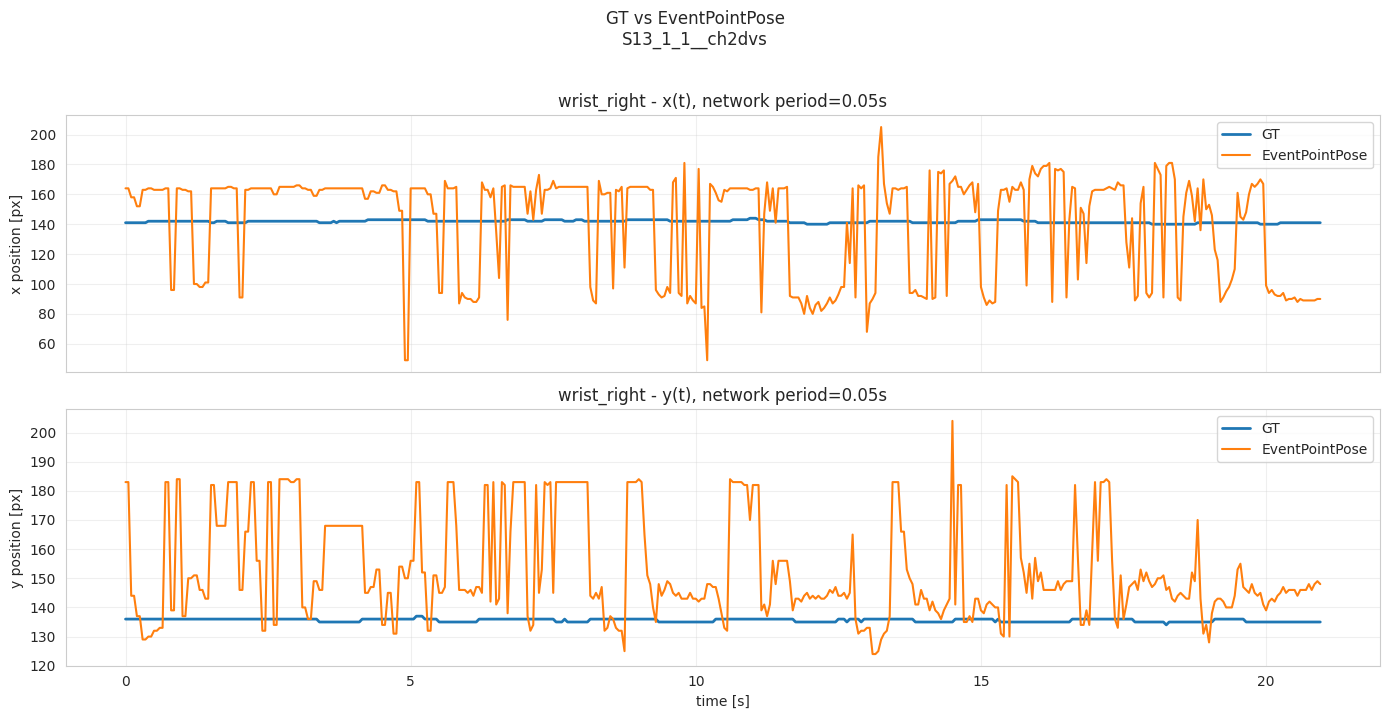

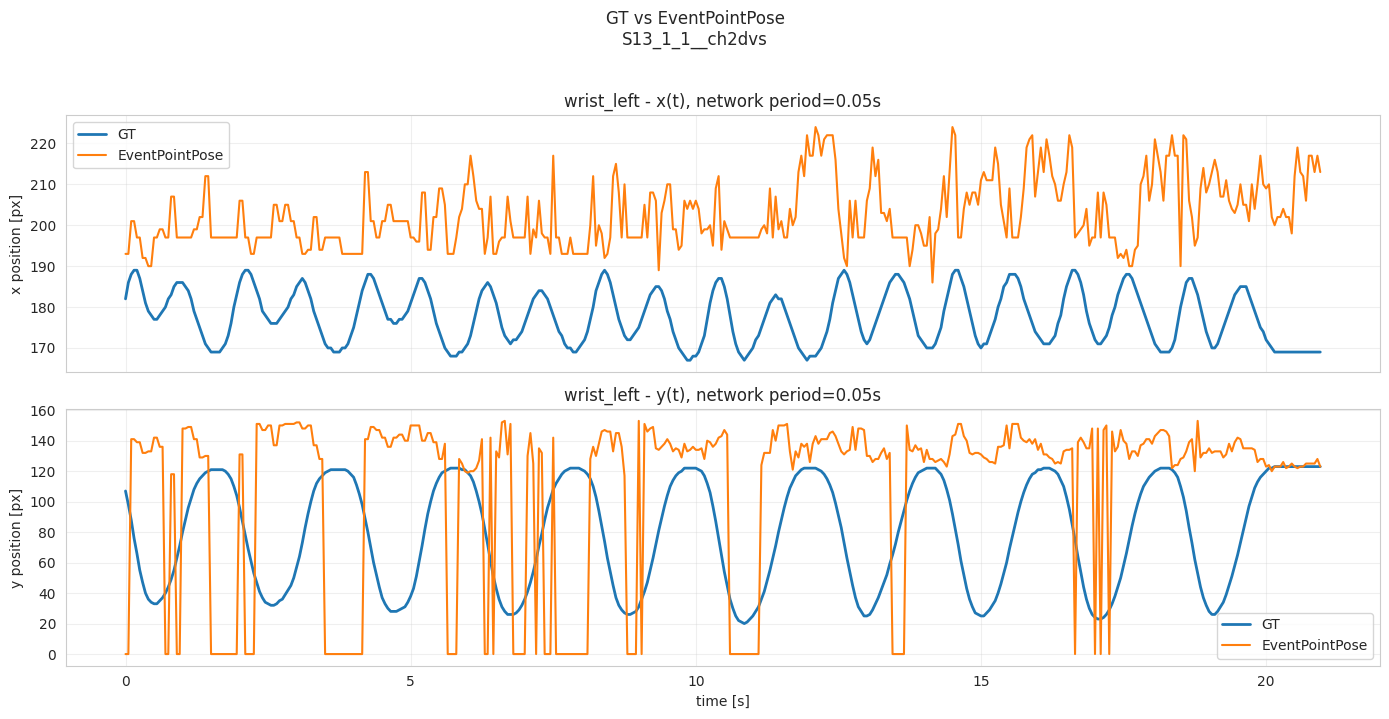

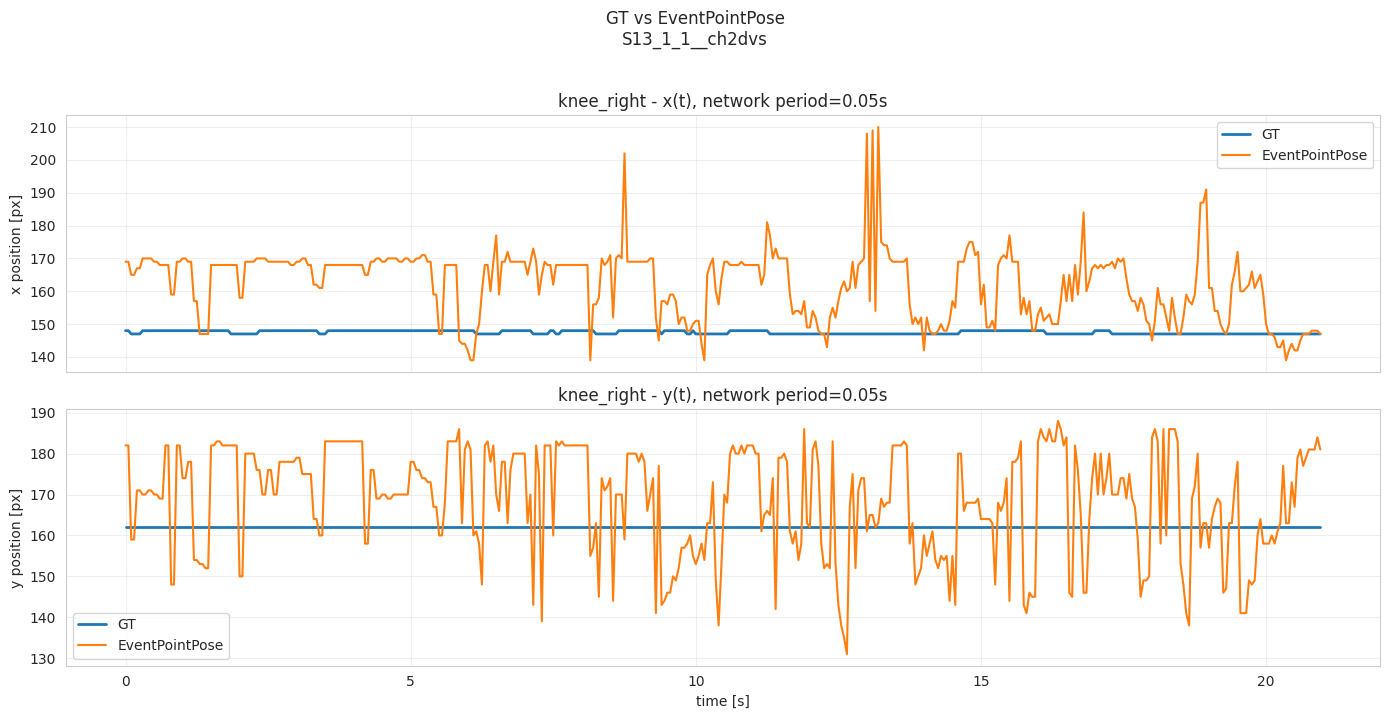

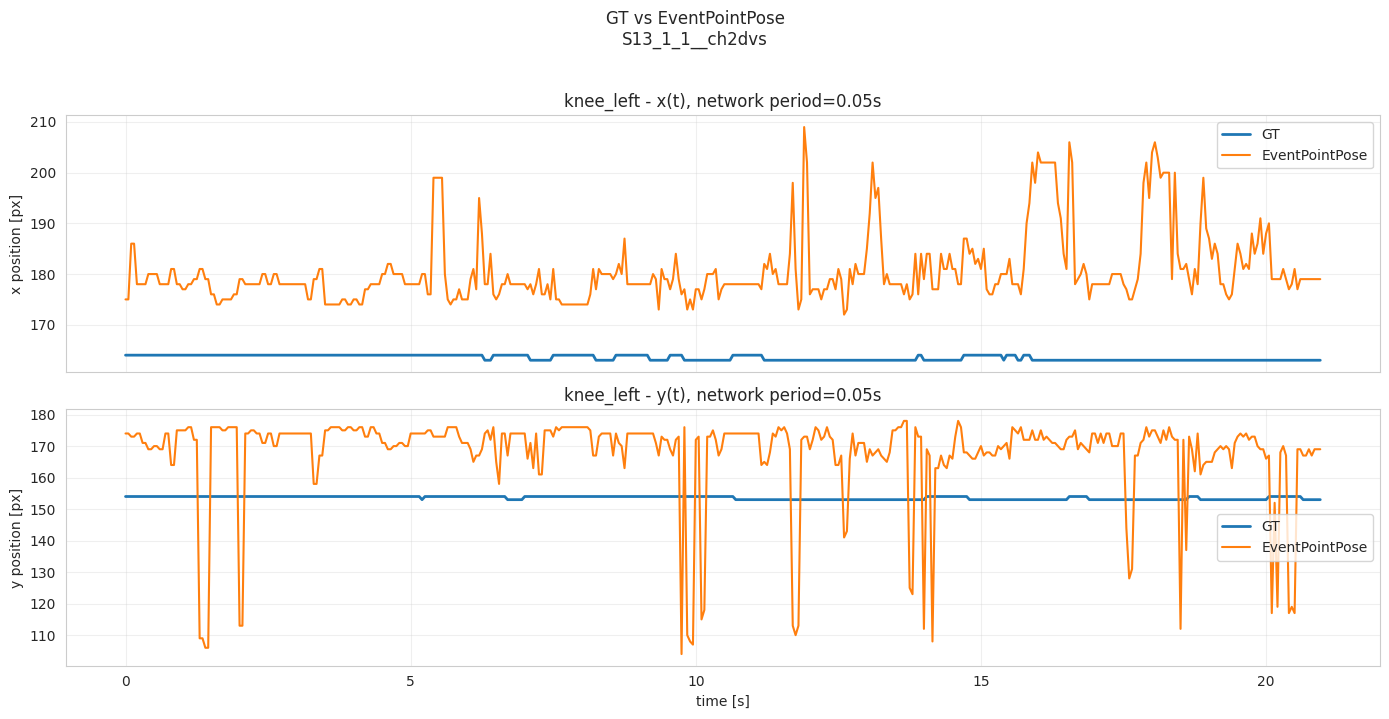

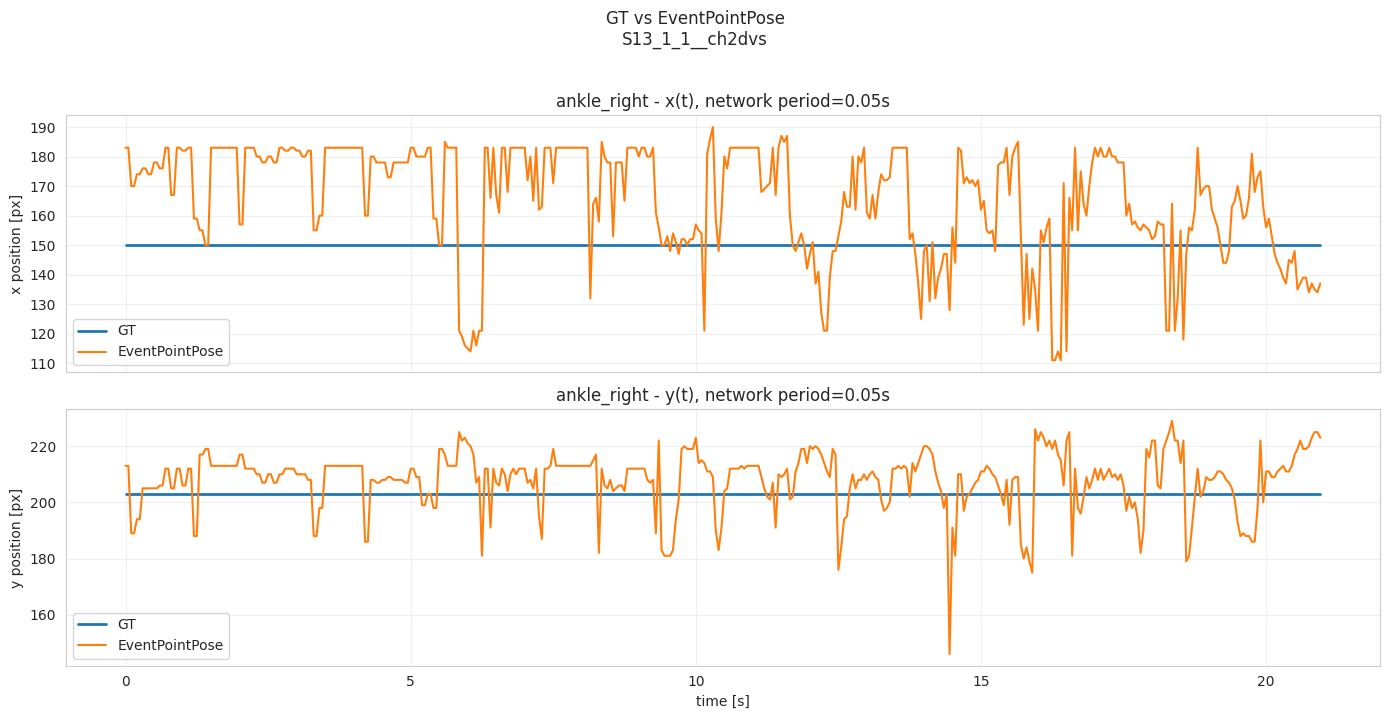

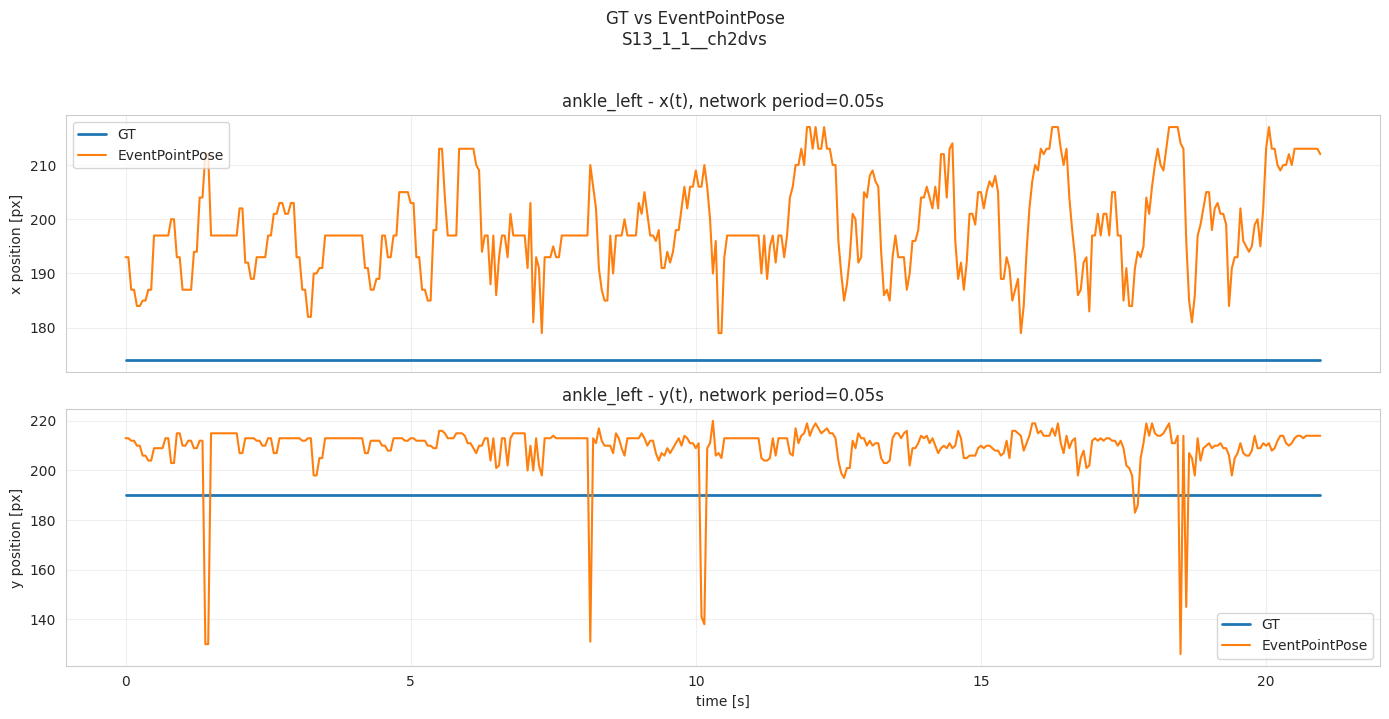

Saved PDF: /workspace/moveEnetFlow/experiments/ExpA/EPP_expA_accuracy_vs_network_period/dhp19_full_test/plots/timed_joint_comparison/S13_1_1__ch2dvs_gt_vs_eventpointpose_np_0p05.pdf


In [19]:
# -----------------------------------------------------------------------------
# GT vs EventPointPose time traces for one selected sequence/configuration
# -----------------------------------------------------------------------------
# The output is one PDF page per joint, with x(t) and y(t).
# -----------------------------------------------------------------------------
from matplotlib.backends.backend_pdf import PdfPages

SELECTED_SEQUENCE = None
# Example:
# SELECTED_SEQUENCE = 'S13_1_1__ch2dvs'

SELECTED_NETWORK_PERIOD = 0.05

# Optional crop in the original sequence timestamp domain.
TIME_START = None
TIME_END = None


def crop_by_time(ts, joints, t_start=None, t_end=None):
    mask = np.ones_like(ts, dtype=bool)

    if t_start is not None:
        mask &= ts >= t_start

    if t_end is not None:
        mask &= ts <= t_end

    return ts[mask], joints[mask]


available = df_seq[
    np.isclose(
        df_seq['network_period_s'],
        SELECTED_NETWORK_PERIOD,
    )
].copy()

if len(available) == 0:
    raise RuntimeError(
        'No EventPointPose rows found for '
        f'network_period={SELECTED_NETWORK_PERIOD}'
    )

if SELECTED_SEQUENCE is None:
    SELECTED_SEQUENCE = sorted(
        available['sequence'].unique()
    )[0]
    print('SELECTED_SEQUENCE was None, using:', SELECTED_SEQUENCE)

selected_rows = available[
    available['sequence'] == SELECTED_SEQUENCE
].copy()

if len(selected_rows) != 1:
    raise RuntimeError(
        f'Expected one row for sequence={SELECTED_SEQUENCE}, '
        f'network_period={SELECTED_NETWORK_PERIOD}; '
        f'found {len(selected_rows)}'
    )

csv_path = Path(selected_rows.iloc[0]['csv_path'])
gt_path = gt_path_from_seq_key(SELECTED_SEQUENCE)

print('Prediction CSV:', csv_path)
print('GT file:       ', gt_path)

ts_pred, joints_pred = load_pred_eval_csv(csv_path)

gt_data = ds_parsing.import_yarp_skeleton_data(
    gt_path,
    multi_channel=False,
)
joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)

ts_plot, joints_pred_plot = crop_by_time(
    ts_pred,
    joints_pred,
    TIME_START,
    TIME_END,
)
_, joints_gt_plot = crop_by_time(
    ts_pred,
    joints_gt,
    TIME_START,
    TIME_END,
)

if len(ts_plot) == 0:
    raise RuntimeError(
        'Time crop produced no samples. Check TIME_START and TIME_END.'
    )

relative_time = ts_plot - ts_plot[0]

time_plot_dir = PLOTS_DIR / 'timed_joint_comparison'
time_plot_dir.mkdir(parents=True, exist_ok=True)

safe_sequence = (
    SELECTED_SEQUENCE
    .replace('/', '__')
    .replace(' ', '_')
)
safe_period = str(SELECTED_NETWORK_PERIOD).replace('.', 'p')

pdf_path = (
    time_plot_dir
    / (
        f'{safe_sequence}_gt_vs_eventpointpose_'
        f'np_{safe_period}.pdf'
    )
)

with PdfPages(pdf_path) as pdf:
    for joint_index, joint_name in enumerate(joint_names):
        fig, axes = plt.subplots(
            2,
            1,
            figsize=(14, 7),
            sharex=True,
        )

        axes[0].plot(
            relative_time,
            joints_gt_plot[:, joint_index, 0],
            linewidth=2,
            label='GT',
        )
        axes[0].plot(
            relative_time,
            joints_pred_plot[:, joint_index, 0],
            linewidth=1.5,
            label='EventPointPose',
        )
        axes[0].set_ylabel('x position [px]')
        axes[0].set_title(
            f'{joint_name} - x(t), '
            f'network period={SELECTED_NETWORK_PERIOD:g}s'
        )
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].plot(
            relative_time,
            joints_gt_plot[:, joint_index, 1],
            linewidth=2,
            label='GT',
        )
        axes[1].plot(
            relative_time,
            joints_pred_plot[:, joint_index, 1],
            linewidth=1.5,
            label='EventPointPose',
        )
        axes[1].set_ylabel('y position [px]')
        axes[1].set_xlabel('time [s]')
        axes[1].set_title(
            f'{joint_name} - y(t), '
            f'network period={SELECTED_NETWORK_PERIOD:g}s'
        )
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        fig.suptitle(
            f'GT vs EventPointPose\n{SELECTED_SEQUENCE}',
            y=1.02,
        )
        plt.tight_layout()

        pdf.savefig(fig, bbox_inches='tight')
        plt.show()
        plt.close(fig)

print('Saved PDF:', pdf_path)